In [6]:
import seaborn as sns
import os
import sqlite3
import sklearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [1]:
import os
import json
import pandas as pd
import sqlite3

log_dir = "../data/merged_raw_data"       
db_path = "logs.db"
tabels = []

conn = sqlite3.connect(db_path)

for file in os.listdir(log_dir):
    if file.endswith(".log"):
        file_path = os.path.join(log_dir, file)
        all_logs = []

        # Read JSON lines
        with open(file_path, "r") as f:
            for line in f:
                line = line.strip()
                if line:  # skip empty lines
                    all_logs.append(json.loads(line))

        # Convert to DataFrame
        df = pd.DataFrame(all_logs)

        # Flatten list columns for SQLite
        for col in df.columns:
            if df[col].apply(lambda x: isinstance(x, list)).any():
                df[col] = df[col].apply(lambda x: ", ".join(map(str, x)) if isinstance(x, list) else x)

        # Clean table name
        table_name = file.replace(".log", "").replace("-", "_")

        # Write to SQLite
        df.to_sql(table_name, conn, if_exists="replace", index=False)
        tabels.append(table_name)
        print(f"Loaded {file} → table `{table_name}`")


conn.close()


Loaded all-conn.log → table `all_conn`
Loaded all-dns.log → table `all_dns`
Loaded all-dpd.log → table `all_dpd`
Loaded all-files.log → table `all_files`
Loaded all-http.log → table `all_http`
Loaded all-kerberos.log → table `all_kerberos`
Loaded all-ntp.log → table `all_ntp`
Loaded all-packet_filter.log → table `all_packet_filter`
Loaded all-reporter.log → table `all_reporter`
Loaded all-sip.log → table `all_sip`
Loaded all-snmp.log → table `all_snmp`
Loaded all-tunnel.log → table `all_tunnel`
Loaded all-weird.log → table `all_weird`


In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("logs.db")

for table in tabels:
    print(f"Processing table {table}...")

    # Load table into pandas
    df = pd.read_sql(f"SELECT * FROM {table};", conn)

    if 'ts' in df.columns:
        # Sort by timestamp
        df = df.sort_values('ts')
        min_ts = df['ts'].min()

        # Integer bucket: each bucket = 1 minute from min_ts
        df['time_bucket_id'] = ((df['ts'] - min_ts) // 86400).astype(int)

        # Replace table with updated version in SQLite
        df.to_sql(table, conn, if_exists="replace", index=False)
        print(f"Updated {table} with {len(df)} rows and time_bucket_id column")
    else:
        print(f"Table {table} has no 'ts' column; skipped")

conn.close()

Processing table all_conn...
Updated all_conn with 774766 rows and time_bucket_id column
Processing table all_dns...
Updated all_dns with 2347 rows and time_bucket_id column
Processing table all_dpd...
Updated all_dpd with 242 rows and time_bucket_id column
Processing table all_files...
Updated all_files with 26571 rows and time_bucket_id column
Processing table all_http...
Updated all_http with 28051 rows and time_bucket_id column
Processing table all_kerberos...
Updated all_kerberos with 10 rows and time_bucket_id column
Processing table all_ntp...
Updated all_ntp with 170 rows and time_bucket_id column
Processing table all_packet_filter...
Updated all_packet_filter with 5495 rows and time_bucket_id column
Processing table all_reporter...
Updated all_reporter with 3197 rows and time_bucket_id column
Processing table all_sip...
Updated all_sip with 31270 rows and time_bucket_id column
Processing table all_snmp...
Updated all_snmp with 810 rows and time_bucket_id column
Processing tabl

In [4]:
conn = sqlite3.connect("logs.db")

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
tables = tables['name'].tolist()

plot_data = pd.DataFrame()

for table in tables:
    df = pd.read_sql(f"""
        SELECT time_bucket_id, COUNT(*) as msg_count
        FROM {table}
        GROUP BY time_bucket_id
    """, conn)
    
    df['log_type'] = table  
    plot_data = pd.concat([plot_data, df], ignore_index=True)

conn.close()
print(plot_data.head(10))

   time_bucket_id  msg_count  log_type
0               0        597  all_conn
1               2       1627  all_conn
2               3       2023  all_conn
3               4       1665  all_conn
4               5       1836  all_conn
5               6       1870  all_conn
6               7       1993  all_conn
7               8       1986  all_conn
8               9       1851  all_conn
9              10       1835  all_conn


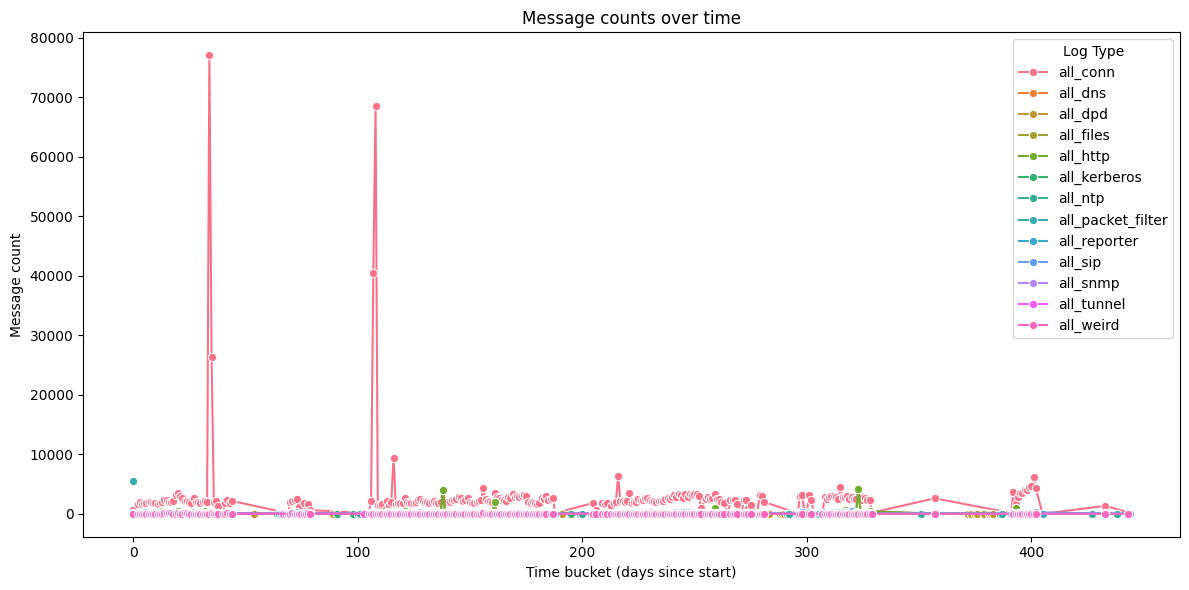

In [11]:
# Then plot the same way
plt.figure(figsize=(12,6))
sns.lineplot(
    data=plot_data,
    x='time_bucket_id',
    y='msg_count',
    hue='log_type',
    marker='o'
)

plt.title("Message counts over time")
plt.xlabel("Time bucket (days since start)")
plt.ylabel("Message count")
plt.legend(title="Log Type")
plt.tight_layout()
plt.show()

In [9]:
conn = sqlite3.connect("logs.db")

# --- all_conn aggregations ---
conn_features = pd.read_sql("""
    SELECT
        time_bucket_id,
        COUNT(*)                                            AS conn_count,
        COUNT(DISTINCT "id.orig_h")                        AS unique_src_ips,
        COUNT(DISTINCT "id.resp_h")                        AS unique_dst_ips,
        COUNT(DISTINCT "id.resp_p")                        AS unique_dst_ports,
        SUM(CAST(orig_bytes AS REAL))                      AS total_orig_bytes,
        SUM(CAST(resp_bytes AS REAL))                      AS total_resp_bytes,
        AVG(CAST(duration AS REAL))                        AS avg_duration,
        SUM(CASE WHEN conn_state IN ('S0','REJ','RSTO','RSTOS0','RSTRH') THEN 1 ELSE 0 END) AS failed_conns,
        SUM(CASE WHEN proto = 'tcp' THEN 1 ELSE 0 END)    AS tcp_count,
        SUM(CASE WHEN proto = 'udp' THEN 1 ELSE 0 END)    AS udp_count
    FROM all_conn
    GROUP BY time_bucket_id
""", conn)

# --- all_dns aggregations ---
dns_features = pd.read_sql("""
    SELECT
        time_bucket_id,
        COUNT(*)                AS dns_count,
        COUNT(DISTINCT query)   AS unique_domains,
        SUM(CASE WHEN rcode_name = 'NXDOMAIN' THEN 1 ELSE 0 END) AS nxdomain_count
    FROM all_dns
    GROUP BY time_bucket_id
""", conn)

# --- all_http aggregations ---
http_features = pd.read_sql("""
    SELECT
        time_bucket_id,
        COUNT(*)                AS http_count,
        COUNT(DISTINCT host)    AS unique_hosts
    FROM all_http
    GROUP BY time_bucket_id
""", conn)

# --- all_weird aggregations ---
weird_features = pd.read_sql("""
    SELECT
        time_bucket_id,
        COUNT(*) AS weird_count
    FROM all_weird
    GROUP BY time_bucket_id
""", conn)

conn.close()

# --- Merge all into one feature DataFrame ---
features = conn_features \
    .merge(dns_features,   on='time_bucket_id', how='left') \
    .merge(http_features,  on='time_bucket_id', how='left') \
    .merge(weird_features, on='time_bucket_id', how='left') \
    .fillna(0) \
    .sort_values('time_bucket_id') \
    .reset_index(drop=True)

# Derived ratios
features['failed_conn_ratio'] = features['failed_conns'] / features['conn_count'].replace(0, 1)
features['tcp_ratio']         = features['tcp_count']    / features['conn_count'].replace(0, 1)
features['dns_per_http']      = features['dns_count']    / features['http_count'].replace(0, 1)

print(features.shape)
features.head()

(255, 20)


,time_bucket_id,conn_count,unique_src_ips,unique_dst_ips,unique_dst_ports,total_orig_bytes,total_resp_bytes,avg_duration,failed_conns,tcp_count,udp_count,dns_count,unique_domains,nxdomain_count,http_count,unique_hosts,weird_count,failed_conn_ratio,tcp_ratio,dns_per_http
0,0,597,236,34,230,6554.0,2294.0,1.194809,504,424,85,1.0,1.0,0.0,5.0,1.0,2.0,0.844221,0.710218,0.200000
1,2,1627,986,113,292,1340.0,2551.0,0.217099,1430,1282,160,3.0,3.0,0.0,8.0,1.0,26.0,0.878918,0.787953,0.375000
2,3,2023,1125,160,344,5733.0,8694.0,0.242910,1683,1421,287,12.0,7.0,0.0,26.0,2.0,19.0,0.831933,0.702422,0.461538
3,4,1665,973,124,319,1298.0,3144.0,0.229189,1368,1111,262,9.0,9.0,0.0,6.0,1.0,9.0,0.821622,0.667267,1.500000
4,5,1836,1015,117,340,3506.0,4282.0,0.607631,1471,1187,316,15.0,7.0,0.0,15.0,1.0,12.0,0.801198,0.646514,1.000000


In [13]:
conn = sqlite3.connect("logs.db")

# --- all_conn aggregations ---
conn_features = pd.read_sql("""
    SELECT
        time_bucket_id,
        COUNT(*)                                            AS conn_count,
        COUNT(DISTINCT "id.orig_h")                        AS unique_src_ips,
        COUNT(DISTINCT "id.resp_h")                        AS unique_dst_ips,
        COUNT(DISTINCT "id.resp_p")                        AS unique_dst_ports,
        SUM(CAST(orig_bytes AS REAL))                      AS total_orig_bytes,
        SUM(CAST(resp_bytes AS REAL))                      AS total_resp_bytes,
        AVG(CAST(duration AS REAL))                        AS avg_duration,
        SUM(CASE WHEN conn_state IN ('S0','REJ','RSTO','RSTOS0','RSTRH') THEN 1 ELSE 0 END) AS failed_conns,
        SUM(CASE WHEN proto = 'tcp' THEN 1 ELSE 0 END)    AS tcp_count,
        SUM(CASE WHEN proto = 'udp' THEN 1 ELSE 0 END)    AS udp_count
    FROM all_conn
    GROUP BY time_bucket_id
""", conn)

# --- all_dns aggregations ---
dns_features = pd.read_sql("""
    SELECT
        time_bucket_id,
        COUNT(*)                AS dns_count,
        COUNT(DISTINCT query)   AS unique_domains,
        SUM(CASE WHEN rcode_name = 'NXDOMAIN' THEN 1 ELSE 0 END) AS nxdomain_count
    FROM all_dns
    GROUP BY time_bucket_id
""", conn)

# --- all_http aggregations ---
http_features = pd.read_sql("""
    SELECT
        time_bucket_id,
        COUNT(*)                AS http_count,
        COUNT(DISTINCT host)    AS unique_hosts
    FROM all_http
    GROUP BY time_bucket_id
""", conn)

# --- all_weird aggregations ---
weird_features = pd.read_sql("""
    SELECT
        time_bucket_id,
        COUNT(*) AS weird_count
    FROM all_weird
    GROUP BY time_bucket_id
""", conn)

# --- all_files aggregations ---
files_features = pd.read_sql("""
    SELECT
        time_bucket_id,
        COUNT(*)                                                        AS file_count,
        SUM(CAST(total_bytes AS REAL))                                  AS total_file_bytes,
        COUNT(DISTINCT mime_type)                                       AS unique_mime_types,
        SUM(CASE WHEN mime_type IN (
            'application/x-executable', 'application/x-dosexec',
            'application/x-elf', 'application/x-shellscript'
        ) THEN 1 ELSE 0 END)                                            AS executable_file_count
    FROM all_files
    GROUP BY time_bucket_id
""", conn)

# --- all_reporter aggregations ---
reporter_features = pd.read_sql("""
    SELECT
        time_bucket_id,
        COUNT(*)                                                        AS reporter_count,
        SUM(CASE WHEN level = 'Reporter::WARNING' THEN 1 ELSE 0 END)   AS reporter_warnings,
        SUM(CASE WHEN level = 'Reporter::ERROR'   THEN 1 ELSE 0 END)   AS reporter_errors
    FROM all_reporter
    GROUP BY time_bucket_id
""", conn)

# --- all_snmp aggregations ---
snmp_features = pd.read_sql("""
    SELECT
        time_bucket_id,
        COUNT(*)                            AS snmp_count,
        SUM(CAST(get_requests AS REAL))     AS snmp_get_requests,
        SUM(CAST(set_requests AS REAL))     AS snmp_set_requests
    FROM all_snmp
    GROUP BY time_bucket_id
""", conn)

# --- all_dpd aggregations ---
dpd_features = pd.read_sql("""
    SELECT
        time_bucket_id,
        COUNT(*) AS dpd_count
    FROM all_dpd
    GROUP BY time_bucket_id
""", conn)

# --- all_tunnel aggregations ---
tunnel_features = pd.read_sql("""
    SELECT
        time_bucket_id,
        COUNT(*)                    AS tunnel_count,
        COUNT(DISTINCT tunnel_type) AS unique_tunnel_types
    FROM all_tunnel
    GROUP BY time_bucket_id
""", conn)

conn.close()

# --- Merge all into one feature DataFrame ---
features = conn_features \
    .merge(dns_features,      on='time_bucket_id', how='left') \
    .merge(http_features,     on='time_bucket_id', how='left') \
    .merge(weird_features,    on='time_bucket_id', how='left') \
    .merge(files_features,    on='time_bucket_id', how='left') \
    .merge(reporter_features, on='time_bucket_id', how='left') \
    .merge(snmp_features,     on='time_bucket_id', how='left') \
    .merge(dpd_features,      on='time_bucket_id', how='left') \
    .merge(tunnel_features,   on='time_bucket_id', how='left') \
    .fillna(0) \
    .sort_values('time_bucket_id') \
    .reset_index(drop=True)

# Derived ratios
features['failed_conn_ratio'] = features['failed_conns']  / features['conn_count'].replace(0, 1)
features['tcp_ratio']         = features['tcp_count']      / features['conn_count'].replace(0, 1)
features['dns_per_http']      = features['dns_count']      / features['http_count'].replace(0, 1)
features['snmp_write_ratio']  = features['snmp_set_requests'] / (features['snmp_get_requests'] + features['snmp_set_requests']).replace(0, 1)

print(features.shape)
features.head()

(255, 34)


,time_bucket_id,conn_count,unique_src_ips,unique_dst_ips,unique_dst_ports,total_orig_bytes,total_resp_bytes,avg_duration,failed_conns,tcp_count,...,snmp_count,snmp_get_requests,snmp_set_requests,dpd_count,tunnel_count,unique_tunnel_types,failed_conn_ratio,tcp_ratio,dns_per_http,snmp_write_ratio
0,0,597,236,34,230,6554.0,2294.0,1.194809,504,424,...,3.0,5.0,0.0,1.0,10.0,1.0,0.844221,0.710218,0.200000,0.0
1,2,1627,986,113,292,1340.0,2551.0,0.217099,1430,1282,...,1.0,2.0,0.0,0.0,6.0,1.0,0.878918,0.787953,0.375000,0.0
2,3,2023,1125,160,344,5733.0,8694.0,0.242910,1683,1421,...,3.0,4.0,0.0,0.0,2.0,1.0,0.831933,0.702422,0.461538,0.0
3,4,1665,973,124,319,1298.0,3144.0,0.229189,1368,1111,...,4.0,4.0,0.0,0.0,2.0,1.0,0.821622,0.667267,1.500000,0.0
4,5,1836,1015,117,340,3506.0,4282.0,0.607631,1471,1187,...,2.0,4.0,0.0,1.0,6.0,1.0,0.801198,0.646514,1.000000,0.0


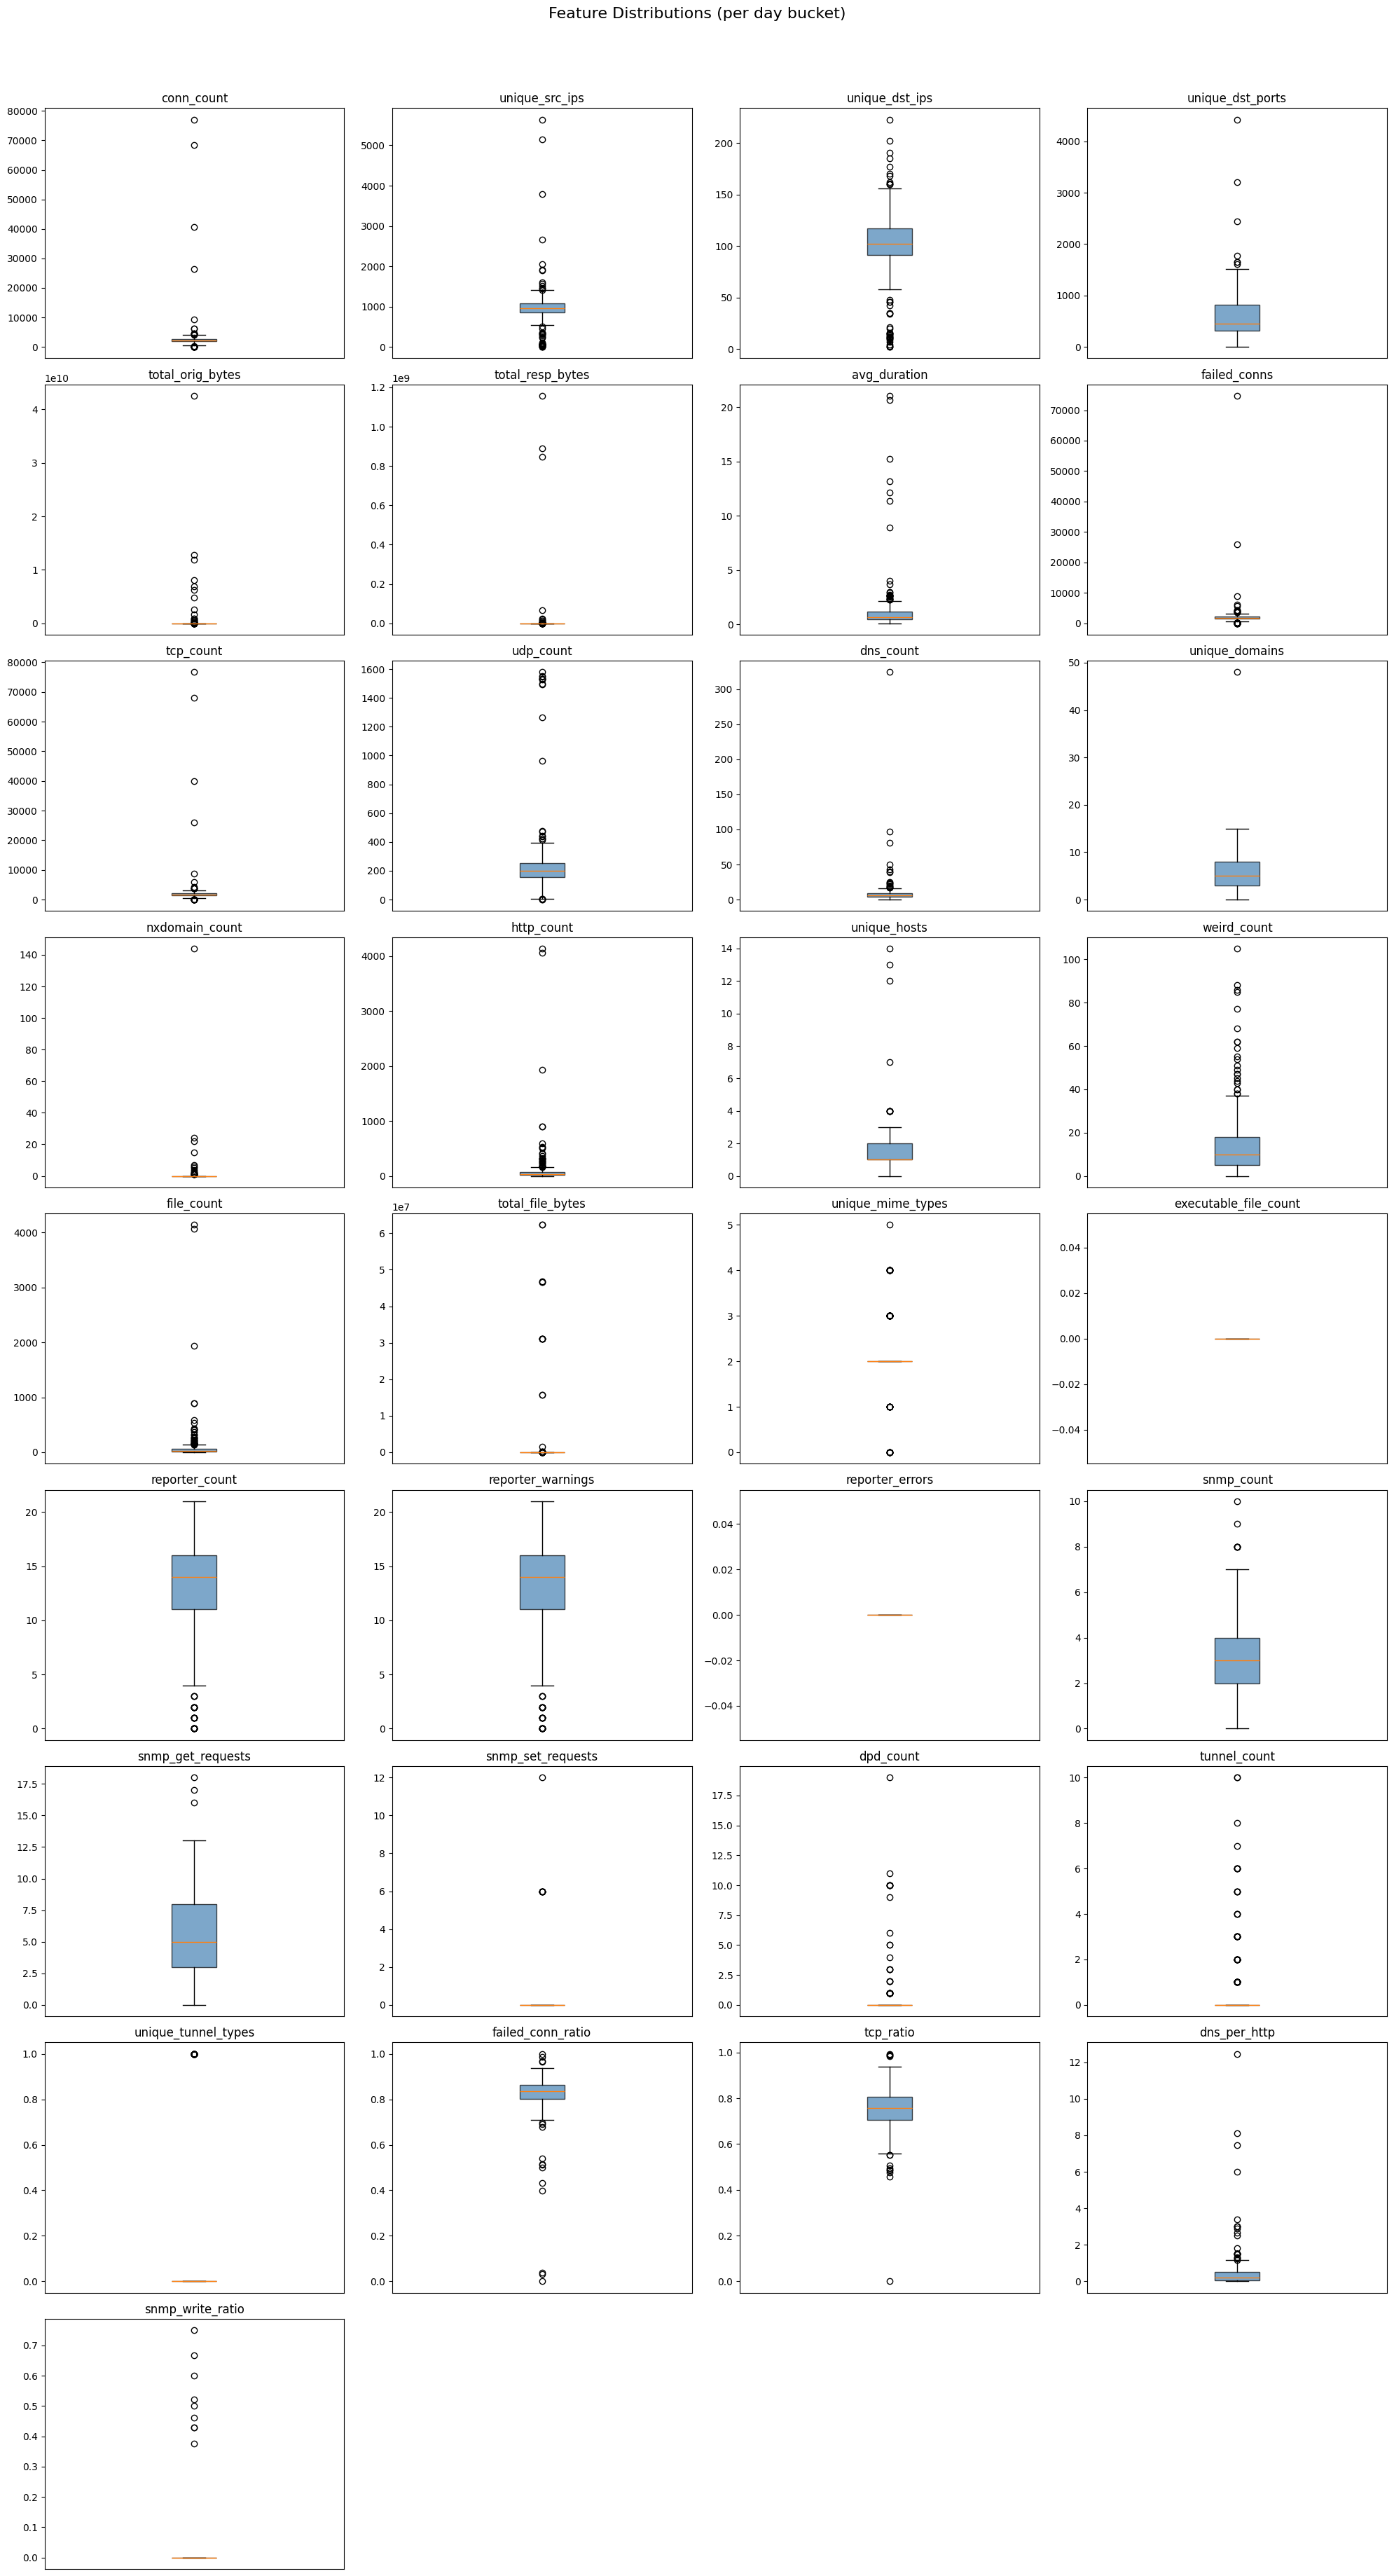

In [15]:
plot_features = [col for col in features.columns if col != 'time_bucket_id']

n_cols = 4
n_rows = -(-len(plot_features) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(plot_features):
    axes[i].boxplot(features[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col)
    axes[i].set_xticks([])

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions (per day bucket)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


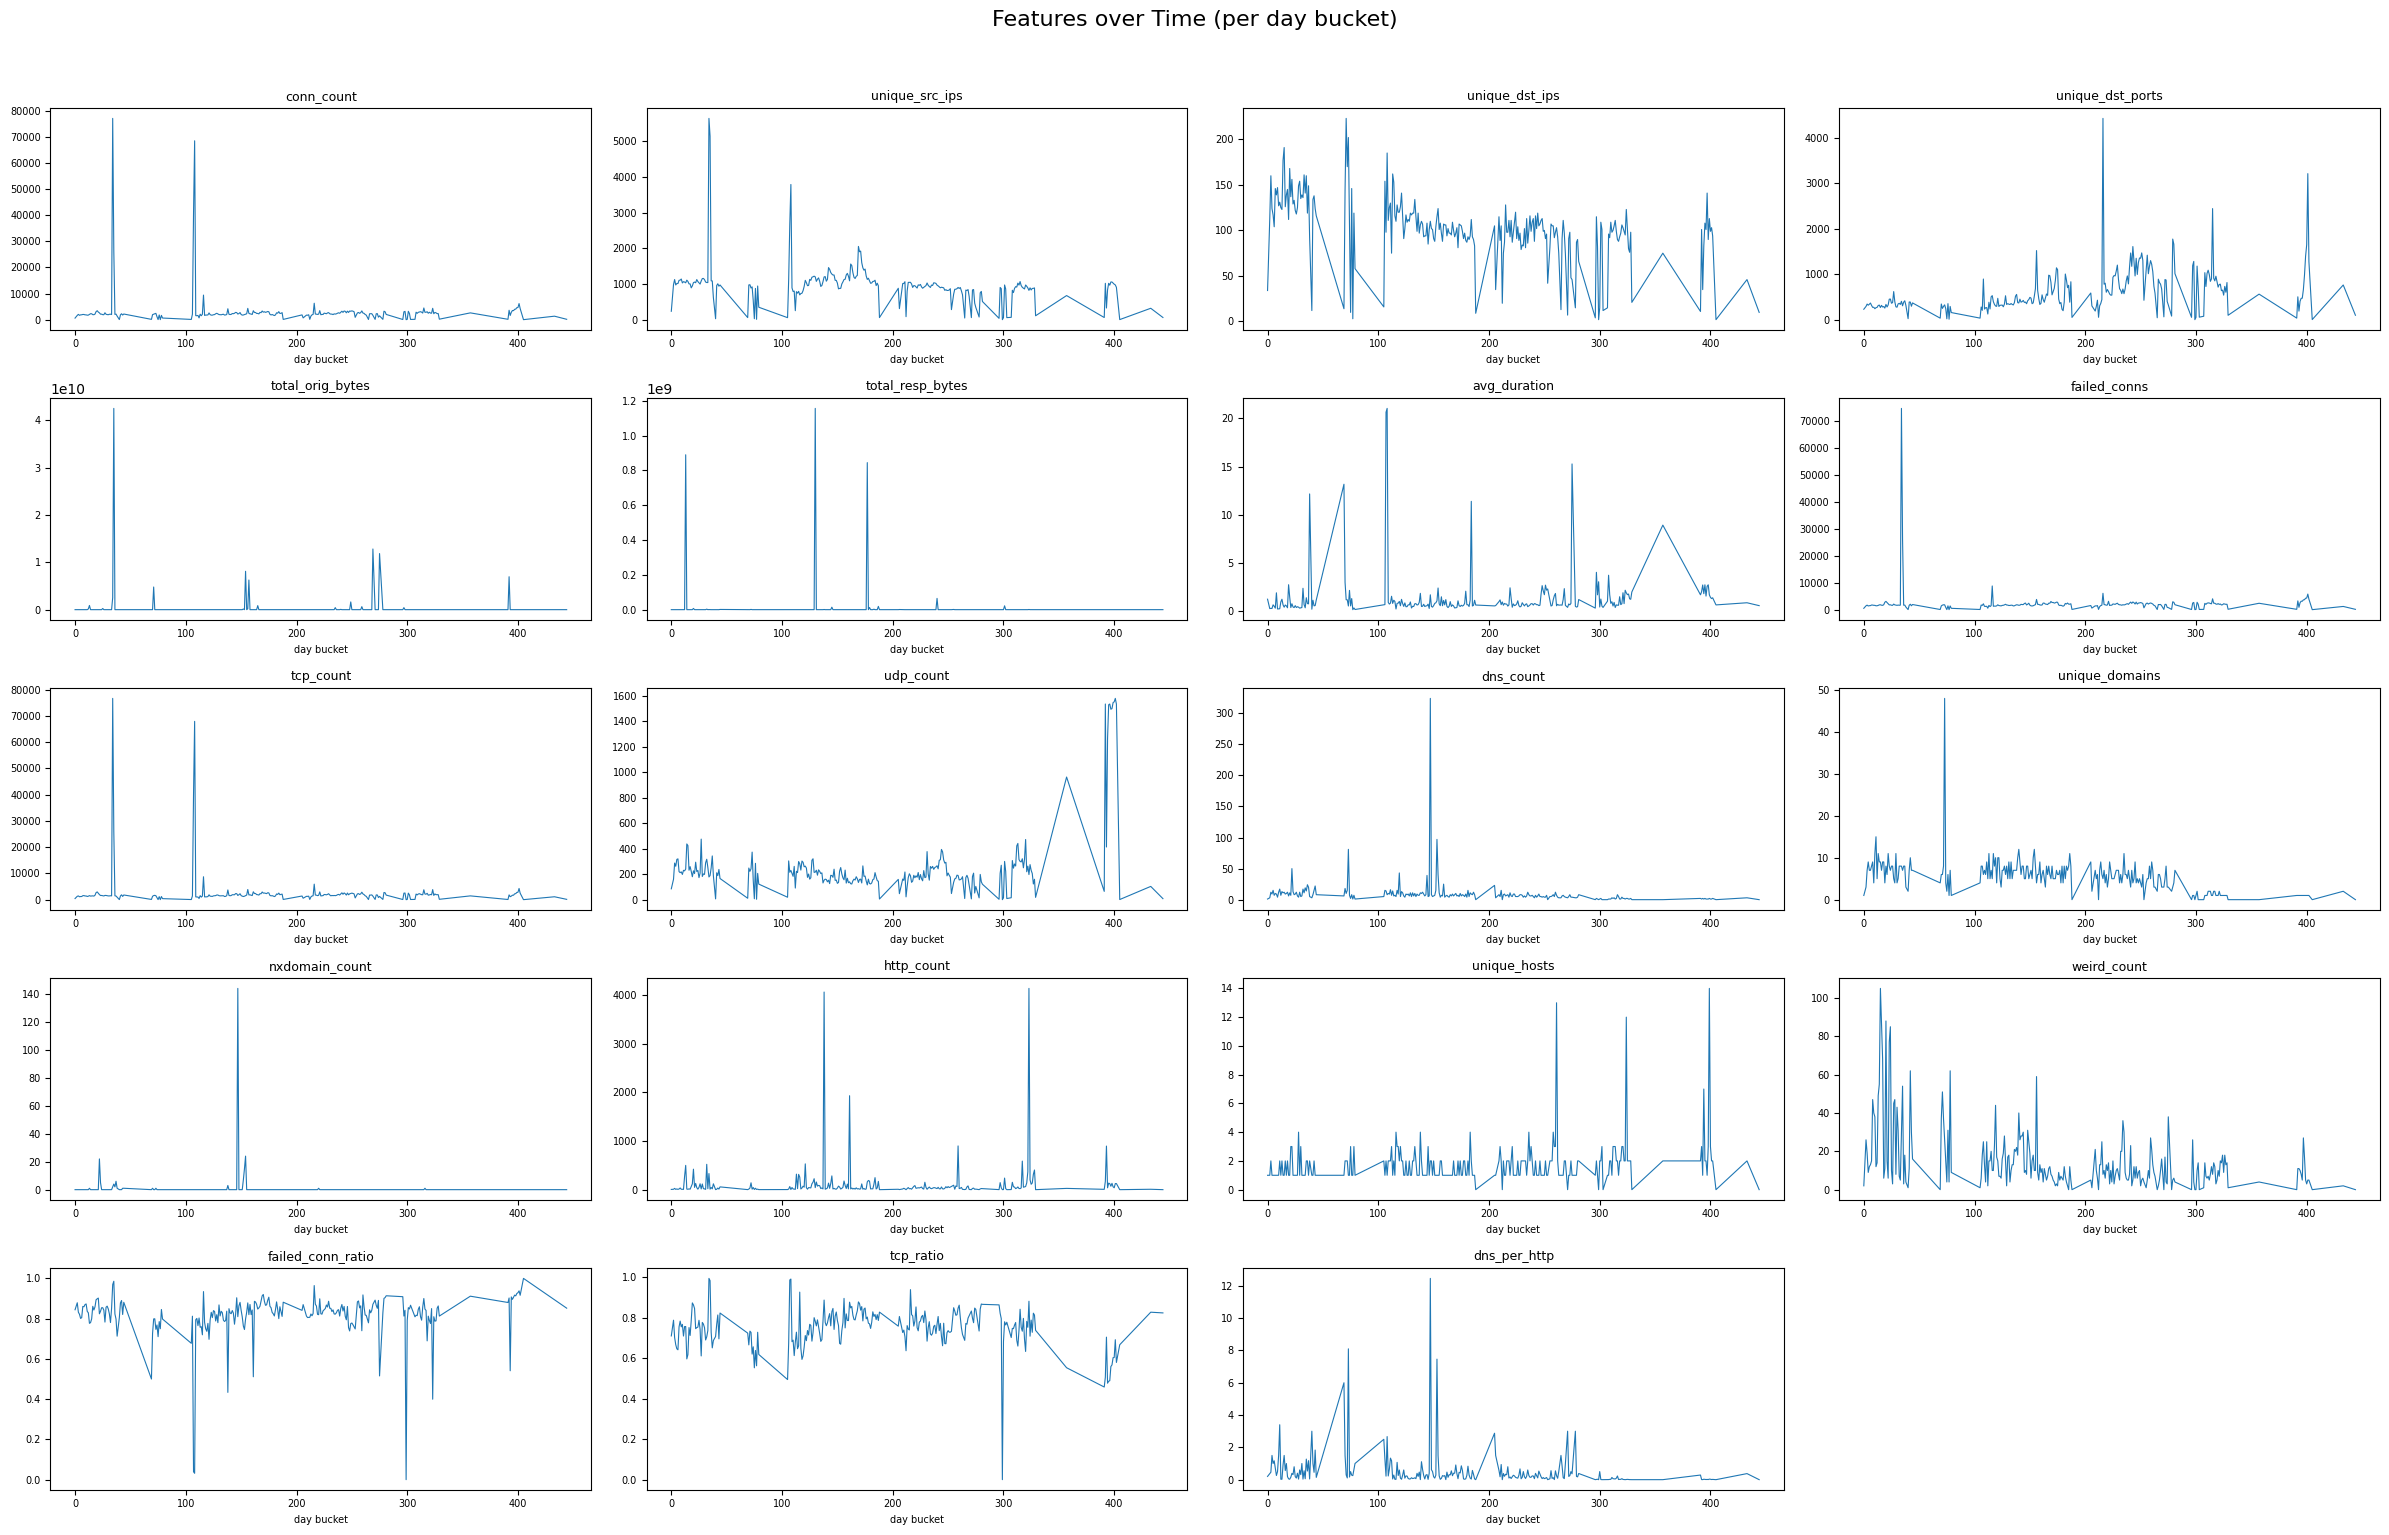

In [14]:
n_cols = 4
n_rows = -(-len(plot_features) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(plot_features):
    axes[i].plot(features['time_bucket_id'], features[col], linewidth=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("day bucket", fontsize=7)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Features over Time (per day bucket)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
features.to_csv("../data/preprocess/features.csv")